# CARLA 20K Semantic Segmentation — **Advanced & Optimized** Pipeline

This is an upgraded version of the original starter tutorial. **All dataset directory paths
are unchanged** (`BASE_DIR`, `CSV_PATH`, `TRAIN_DIR`, `VAL_DIR`) so it drops into the same
Kaggle input structure.

### What's new vs. the starter notebook
| Area | Starter | Advanced |
|---|---|---|
| Mask decoding | Per-pixel broadcast compare against all classes | O(1) GPU **lookup table** (hashed RGB → class id) |
| Augmentation | None | Flip / brightness-contrast / scale-crop / shift via **Albumentations** |
| Loss | CrossEntropy only | **CrossEntropy + Dice** (better for imbalanced classes) |
| Class weights | Python loop over sampled pixels | Vectorized `torch.bincount` over the *full* train set |
| Optimizer/Schedule | AdamW, fixed LR | AdamW + **OneCycleLR** (warmup + cosine decay) |
| Precision | Legacy `torch.cuda.amp` | New `torch.amp` API + grad clipping |
| DataLoader | `num_workers=4` | `num_workers=cpu_count`, `persistent_workers`, `prefetch_factor`, `pin_memory` |
| Metrics | None (loss only) | Per-epoch **mean IoU** via confusion-matrix accumulation |
| Model selection | ResNet50 DeepLabV3 hard-coded | Configurable backbone (`resnet50`/`resnet101`), optional `torch.compile` |
| Training loop | No validation, no checkpoints | Train/val loop, **early stopping**, **best-checkpoint saving** |
| Reproducibility | Not seeded | Global seed for `random`/`numpy`/`torch` |
| Reporting | Two prediction panels | Loss/mIoU curves + prediction grid with **overlay blending** |

Run top-to-bottom on a GPU-enabled Kaggle kernel.


## Imports & Reproducibility

In [1]:
#######################################################################################
# 🚗 CARLA 20K SEMANTIC SEGMENTATION — ADVANCED / OPTIMIZED NOTEBOOK
# Adds: fast LUT mask decoding, augmentation, Dice+CE loss, OneCycle LR,
#       mIoU tracking, early stopping, checkpointing, torch.compile support.
#######################################################################################

import os
import gc
import glob
import random
import time
import warnings
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models.segmentation as seg_models
from tqdm import tqdm

try:
    import albumentations as A
    ALBU_AVAILABLE = True
except ImportError:
    ALBU_AVAILABLE = False

warnings.filterwarnings("ignore")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
seed_everything(SEED)

print("=" * 60)
print("🚀 CARLA 20K SEMANTIC SEGMENTATION — ADVANCED PIPELINE")
print(f"[INFO] Albumentations available: {ALBU_AVAILABLE}")
print("=" * 60)

🚀 CARLA 20K SEMANTIC SEGMENTATION — ADVANCED PIPELINE
[INFO] Albumentations available: True


## 1️ Hardware & Mixed Precision Setup

Enables cuDNN autotuning + the newer `torch.amp` API with gradient scaling and clipping.

In [2]:
use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")

# cuDNN autotuner — picks the fastest conv algorithms for fixed input sizes
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

AMP_DTYPE = torch.bfloat16 if (use_cuda and torch.cuda.is_bf16_supported()) else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=(use_cuda and AMP_DTYPE == torch.float16))

print(f"[INFO] Device: {device} | AMP dtype: {AMP_DTYPE} | GPU: "
      f"{torch.cuda.get_device_name(0) if use_cuda else 'N/A'}")

[INFO] Device: cuda | AMP dtype: torch.bfloat16 | GPU: Tesla T4


## 2️ Dataset Paths & Color Map

**Directory layout is identical to the original notebook — nothing changed here.**

In [3]:
BASE_DIR = "/kaggle/input/datasets/uditkumarrana/carla-semantic-segmentation"
CSV_PATH  = os.path.join(BASE_DIR, "color_dict.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "semantic_segmentation_dataset", "train", "images")
VAL_DIR   = os.path.join(BASE_DIR, "semantic_segmentation_dataset", "val", "images")

print(f"\n[INFO] Loading Color Dictionary from: {CSV_PATH}")
df_colors = pd.read_csv(CSV_PATH)

class_names = df_colors['class_name'].tolist()
class_rgb   = df_colors[['r', 'g', 'b']].to_numpy(dtype=np.uint8)
class_bgr   = class_rgb[:, ::-1].copy()

NUM_CLASSES = len(class_names)
print(f"[INFO] Successfully loaded {NUM_CLASSES} classes.")


[INFO] Loading Color Dictionary from: /kaggle/input/datasets/uditkumarrana/carla-semantic-segmentation/color_dict.csv
[INFO] Successfully loaded 13 classes.


## 3️ Optimized Mask Decoding — GPU Lookup Table

The starter notebook decodes every mask by broadcasting each pixel against **all** class
colors (`O(H·W·C)` comparisons). Instead, we pack each RGB triple into a single 24-bit integer
and build a **256³ lookup table** once. Decoding then becomes a single `gather` — `O(H·W)` —
which is dramatically faster and scales to any number of classes.


In [4]:
def _rgb_to_key(rgb: np.ndarray) -> np.ndarray:
    rgb = rgb.astype(np.int64)
    return (rgb[..., 0] << 16) | (rgb[..., 1] << 8) | rgb[..., 2]

# Build a 256*256*256 LUT mapping packed-RGB -> class id (covers RGB and BGR palettes)
_LUT_SIZE = 256 ** 3
lut = np.full(_LUT_SIZE, fill_value=-1, dtype=np.int32)
lut[_rgb_to_key(class_rgb)] = np.arange(NUM_CLASSES, dtype=np.int32)
lut[_rgb_to_key(class_bgr)] = np.arange(NUM_CLASSES, dtype=np.int32)

lut_t = torch.from_numpy(lut).long().to(device)

def decode_mask_gpu(lbl_rgb_uint8: torch.Tensor) -> torch.Tensor:
    # Vectorized RGB/BGR -> class-id decoding via GPU lookup table.
    # lbl_rgb_uint8: (..., H, W, 3) uint8 tensor on `device`.
    # Returns: (..., H, W) long tensor of class ids (0 for unmatched/void pixels).
    x = lbl_rgb_uint8.long()
    key = (x[..., 0] << 16) | (x[..., 1] << 8) | x[..., 2]
    ids = lut_t[key]
    ids = torch.clamp(ids, min=0).long()  # unmatched -> class 0; cast to int64 for loss/index ops
    return ids

print("[INFO] Built GPU lookup table for O(H*W) mask decoding "
      f"({_LUT_SIZE:,} entries, {NUM_CLASSES} classes mapped).")

[INFO] Built GPU lookup table for O(H*W) mask decoding (16,777,216 entries, 13 classes mapped).


## 4️ Augmentation Pipeline

Train-time augmentation (flip, brightness/contrast, shift-scale-rotate, random crop) improves generalization; validation only gets deterministic resize + normalize. Falls back gracefully if `albumentations` isn't installed.

In [5]:
IMG_H, IMG_W = 256, 512  # same resolution as the starter notebook; raise for better accuracy
img_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

if ALBU_AVAILABLE:
    train_aug = A.Compose([
        A.Resize(IMG_H, IMG_W, interpolation=cv2.INTER_LINEAR),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=5,
                            border_mode=cv2.BORDER_CONSTANT, p=0.3),
        A.GaussNoise(var_limit=(5.0, 20.0), p=0.15),
    ])
    val_aug = A.Compose([
        A.Resize(IMG_H, IMG_W, interpolation=cv2.INTER_LINEAR),
    ])
else:
    train_aug = val_aug = None

print(f"[INFO] Train resolution: {IMG_H}x{IMG_W} | Augmentation enabled: {ALBU_AVAILABLE}")

[INFO] Train resolution: 256x512 | Augmentation enabled: True


## 5️ Dataset Class

Same `.npz` loading contract as the starter notebook, extended with optional augmentation and mask-aware resizing (nearest-neighbor for masks, linear for images).

In [6]:
class CARLASegDataset(Dataset):
    def __init__(self, npz_dir: str, augment: bool = False):
        self.files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
        assert len(self.files) > 0, f"No data found in {npz_dir}"
        self.augment = augment and ALBU_AVAILABLE
        self.aug = train_aug if (augment and ALBU_AVAILABLE) else val_aug

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        img_bgr = data["image"]
        lbl_raw = data["label"]

        if self.aug is not None:
            # Resize handled inside the Albumentations pipeline (mask uses nearest by default
            # because Albumentations auto-selects NEAREST for integer/label-like inputs when
            # we resize image+mask jointly below).
            out = self.aug(image=img_bgr, mask=lbl_raw)
            img_bgr, lbl_raw = out["image"], out["mask"]
        else:
            img_bgr = cv2.resize(img_bgr, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
            lbl_raw = cv2.resize(lbl_raw, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_tensor = img_normalize(TF.to_tensor(img_rgb))
        lbl_tensor_raw = torch.from_numpy(np.ascontiguousarray(lbl_raw))

        return img_tensor, lbl_tensor_raw, img_rgb, lbl_raw

train_ds = CARLASegDataset(TRAIN_DIR, augment=True)
val_ds   = CARLASegDataset(VAL_DIR, augment=False)

print(f"\n[INFO] Dataset Split -> Train: {len(train_ds):,} | Validation: {len(val_ds):,}")


[INFO] Dataset Split -> Train: 14,000 | Validation: 4,000


## 6️ Exploratory Data Analysis


[INFO] Generating EDA Visualizations...


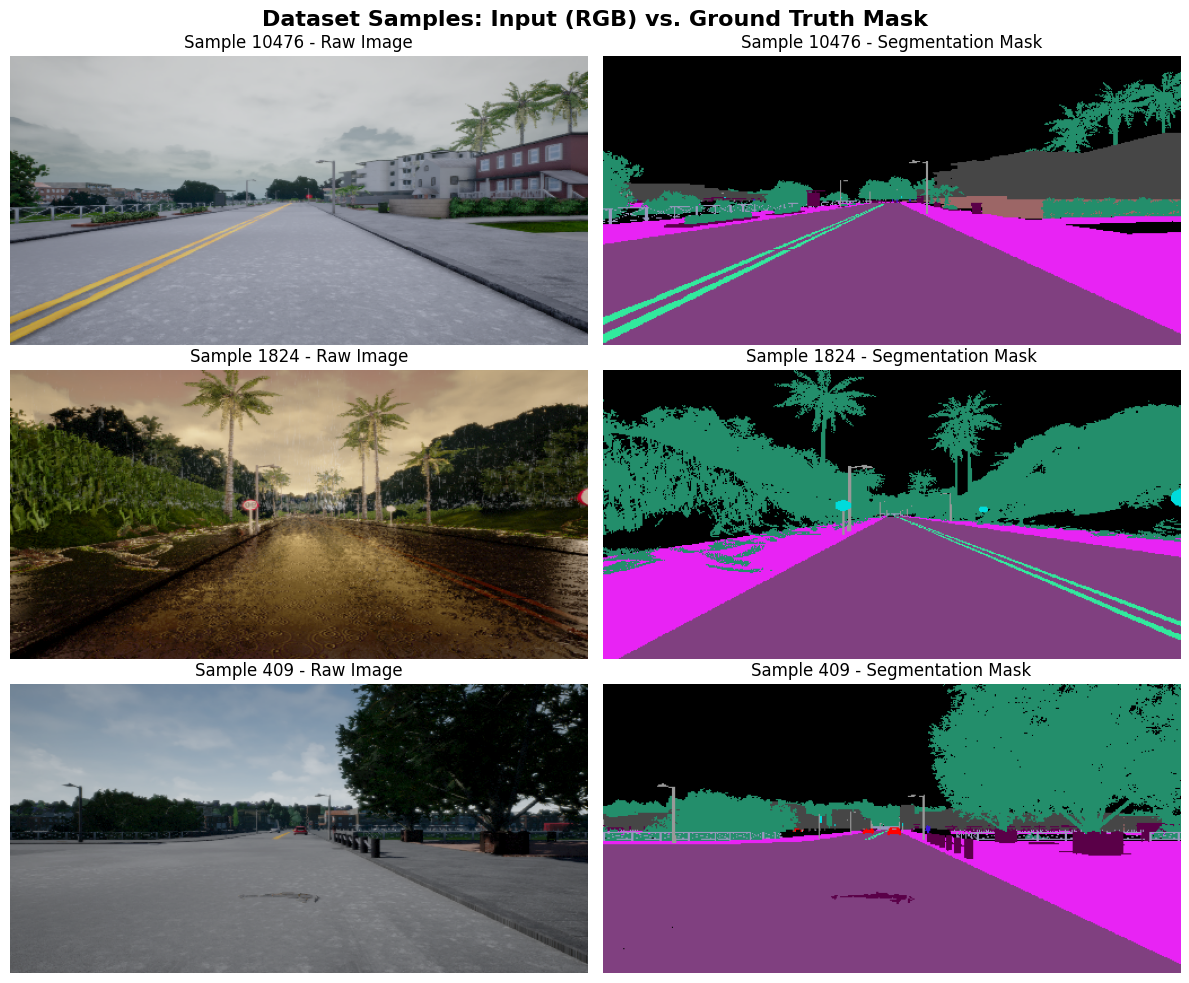

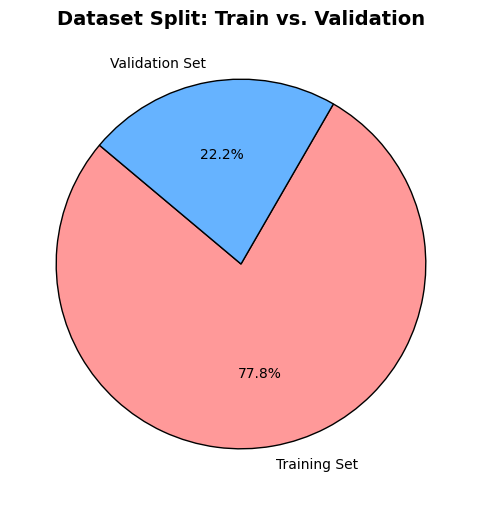

In [7]:
print("\n[INFO] Generating EDA Visualizations...")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle("Dataset Samples: Input (RGB) vs. Ground Truth Mask", fontsize=16, fontweight="bold")

sample_indices = random.sample(range(len(train_ds)), 3)
for i, idx in enumerate(sample_indices):
    _, _, img_rgb, lbl_raw = train_ds[idx]
    lbl_rgb = cv2.cvtColor(lbl_raw, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"Sample {idx} - Raw Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lbl_rgb)
    axes[i, 1].set_title(f"Sample {idx} - Segmentation Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

split_labels = ['Training Set', 'Validation Set']
split_sizes = [len(train_ds), len(val_ds)]
split_colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(7, 6))
plt.pie(split_sizes, labels=split_labels, colors=split_colors, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title("Dataset Split: Train vs. Validation", fontweight="bold", fontsize=14)
plt.show()

## 7️ Class Weighting — Vectorized Full-Dataset Pass

The starter notebook loops in Python over a 300-image sample. Here we accumulate pixel
counts with a single `torch.bincount` call per batch and (optionally) sweep the **entire**
training set using the DataLoader's multiprocessing workers, which is both more accurate
and faster.

In [8]:
def compute_class_frequencies(dataset, max_samples=None, batch_size=64, num_workers=4):
    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    indices = random.sample(range(len(dataset)), n)
    subset = torch.utils.data.Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=use_cuda)

    counts = torch.zeros(NUM_CLASSES, dtype=torch.int64, device=device)
    for _, lbl_raw_batch, _, _ in tqdm(loader, desc="Counting Pixels", ncols=80):
        lbl_raw_batch = lbl_raw_batch.to(device, non_blocking=True)
        mask = decode_mask_gpu(lbl_raw_batch)
        counts += torch.bincount(mask.flatten(), minlength=NUM_CLASSES)

    freq = (counts.float() / counts.sum().clamp(min=1)).cpu().numpy()
    return freq

print("\n[INFO] Computing Class Distribution (vectorized, up to 800 samples)...")
freq = compute_class_frequencies(train_ds, max_samples=min(800, len(train_ds)), num_workers=2)

median_freq   = np.median(freq[freq > 0])
weights       = np.where(freq > 0, median_freq / (freq + 1e-8), 0.0)
weights       = np.clip(weights, 0.1, 20.0)
class_weights = torch.FloatTensor(weights).to(device)

print("\n[INFO] Class Weights (to handle imbalance):")
for i, name in enumerate(class_names):
    print(f"  {name:<15} | Frequency: {freq[i]*100:>6.2f}% | Weight: {weights[i]:.2f}")


[INFO] Computing Class Distribution (vectorized, up to 800 samples)...


Counting Pixels: 100%|██████████████████████████| 13/13 [00:12<00:00,  1.03it/s]


[INFO] Class Weights (to handle imbalance):
  nan             | Frequency:  36.41% | Weight: 0.10
  Buildings       | Frequency:   6.09% | Weight: 0.20
  Fences          | Frequency:   1.47% | Weight: 0.84
  Other           | Frequency:   0.73% | Weight: 1.69
  Pedestrians     | Frequency:   0.03% | Weight: 20.00
  Poles           | Frequency:   0.59% | Weight: 2.09
  RoadLines       | Frequency:   1.01% | Weight: 1.23
  Roads           | Frequency:  32.06% | Weight: 0.10
  Sidewalks       | Frequency:   9.17% | Weight: 0.14
  Vegetation      | Frequency:  11.55% | Weight: 0.11
  Vehicles        | Frequency:   0.00% | Weight: 0.10
  Walls           | Frequency:   0.73% | Weight: 1.70
  TrafficSigns    | Frequency:   0.16% | Weight: 7.84


## 8️ Model, Loss & Optimizer

- Backbone is configurable (`resnet50` default, `resnet101` for higher accuracy at extra cost).
- Loss combines **weighted CrossEntropy** with **Dice loss**, which directly optimizes overlap
  and tends to help segmentation of small/rare classes.
- **OneCycleLR** gives a warmup + cosine-decay schedule, generally converging faster and to a
  better optimum than a fixed learning rate.
- `torch.compile` is used automatically when available (PyTorch 2.x) for a free speed boost.

In [9]:
BACKBONE   = "resnet50"      # "resnet50" or "resnet101"
BATCH      = 32
NUM_EPOCHS = 10              # starter notebook used 2 (demo-only); raise for real training
LR         = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
EARLY_STOP_PATIENCE = 2
CKPT_PATH = "best_model.pt"

NUM_WORKERS = min(8, os.cpu_count() or 4)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                           pin_memory=use_cuda, drop_last=True, persistent_workers=NUM_WORKERS > 0,
                           prefetch_factor=4 if NUM_WORKERS > 0 else None)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS,
                           pin_memory=use_cuda, persistent_workers=NUM_WORKERS > 0,
                           prefetch_factor=4 if NUM_WORKERS > 0 else None)

def build_model(backbone: str, num_classes: int):
    if backbone == "resnet101":
        m = seg_models.deeplabv3_resnet101(weights="DEFAULT")
    else:
        m = seg_models.deeplabv3_resnet50(weights="DEFAULT")
    m.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if hasattr(m, "aux_classifier"):
        m.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    return m

model = build_model(BACKBONE, NUM_CLASSES)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device, memory_format=torch.channels_last if use_cuda else torch.contiguous_format)

# torch.compile (PyTorch 2.x) — graph-compiles the model for faster training/inference
if hasattr(torch, "compile"):
    try:
        model = torch.compile(model)
        print("[INFO] torch.compile enabled.")
    except Exception as e:
        print(f"[WARN] torch.compile unavailable ({e}); continuing without it.")

class DiceLoss(nn.Module):
    def __init__(self, num_classes, eps=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.eps = eps

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_1h = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_1h, dims)
        cardinality = torch.sum(probs + targets_1h, dims)
        dice = (2.0 * intersection + self.eps) / (cardinality + self.eps)
        return 1.0 - dice.mean()

ce_loss   = nn.CrossEntropyLoss(weight=class_weights)
dice_loss = DiceLoss(NUM_CLASSES)

def criterion(logits, targets):
    return ce_loss(logits, targets) + dice_loss(logits, targets)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS
)

print(f"[INFO] Model: DeepLabV3 ({BACKBONE}) | Params: "
      f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 169MB/s]


[INFO] torch.compile enabled.
[INFO] Model: DeepLabV3 (resnet50) | Params: 42.0M


## 9️ Metrics — Mean IoU

Accumulates a confusion matrix per epoch (on GPU) and derives per-class IoU / mean IoU, which
is a far more informative segmentation metric than loss alone.

In [10]:
class ConfusionMatrix:
    def __init__(self, num_classes):
        self.n = num_classes
        self.mat = torch.zeros(num_classes, num_classes, dtype=torch.int64, device=device)

    def update(self, preds, targets):
        k = (targets >= 0) & (targets < self.n)
        inds = self.n * targets[k].to(torch.int64) + preds[k].to(torch.int64)
        self.mat += torch.bincount(inds, minlength=self.n ** 2).reshape(self.n, self.n)

    def reset(self):
        self.mat.zero_()

    def compute_miou(self):
        mat = self.mat.float()
        intersection = torch.diag(mat)
        union = mat.sum(0) + mat.sum(1) - intersection
        iou = intersection / union.clamp(min=1)
        return iou.cpu().numpy(), iou.mean().item()

## 10 Training Loop — AMP + OneCycle + Early Stopping + Checkpointing

In [11]:
def run_epoch(loader, train: bool):
    model.train(mode=train)
    cm = ConfusionMatrix(NUM_CLASSES)
    running_loss, n_samples = 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, desc="Train" if train else "Val", leave=False, ncols=80)

    with ctx:
        for imgs, masks_raw, _, _ in pbar:
            imgs = imgs.to(device, non_blocking=True)
            masks_raw = masks_raw.to(device, non_blocking=True)
            masks = decode_mask_gpu(masks_raw)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_cuda, dtype=AMP_DTYPE):
                outputs = model(imgs)
                out = outputs["out"] if isinstance(outputs, dict) else outputs
                aux = outputs.get("aux") if isinstance(outputs, dict) else None

                loss = criterion(out, masks)
                if aux is not None:
                    loss = loss + 0.4 * criterion(aux, masks)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            running_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)
            cm.update(out.argmax(1), masks)
            pbar.set_postfix(loss=f"{loss.item():.3f}")

    epoch_loss = running_loss / max(n_samples, 1)
    _, miou = cm.compute_miou()
    return epoch_loss, miou


history = {"train_loss": [], "val_loss": [], "train_miou": [], "val_miou": []}
best_miou, patience_left = 0.0, EARLY_STOP_PATIENCE

print(f"\n[INFO] Starting Training ({NUM_EPOCHS} epochs, backbone={BACKBONE}, AMP={use_cuda})...")
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_miou = run_epoch(train_loader, train=True)
    val_loss, val_miou = run_epoch(val_loader, train=False)
    dt = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_miou"].append(tr_miou)
    history["val_miou"].append(val_miou)

    improved = val_miou > best_miou
    if improved:
        best_miou = val_miou
        patience_left = EARLY_STOP_PATIENCE
        torch.save({"model_state": model.state_dict(), "miou": best_miou, "epoch": epoch}, CKPT_PATH)
    else:
        patience_left -= 1

    print(f"Epoch {epoch:>2}/{NUM_EPOCHS} | {dt:5.1f}s | "
          f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_mIoU={tr_miou:.4f} val_mIoU={val_miou:.4f} "
          f"{'⭐ best' if improved else f'(patience {patience_left})'}")

    if patience_left <= 0:
        print(f"[INFO] Early stopping triggered at epoch {epoch} (no val_mIoU improvement "
              f"for {EARLY_STOP_PATIENCE} epochs).")
        break

print(f"\n✅ Training complete. Best validation mIoU: {best_miou:.4f} (checkpoint: {CKPT_PATH})")


[INFO] Starting Training (10 epochs, backbone=resnet50, AMP=True)...


Train:   1%|▏                       | 4/437 [00:33<43:55,  6.09s/it, loss=4.833]W0818 04:11:37.287000 23 torch/_dynamo/convert_frame.py:1676] [3/8] torch._dynamo hit config.recompile_limit (8)
W0818 04:11:37.287000 23 torch/_dynamo/convert_frame.py:1676] [3/8]    function: 'torch_dynamo_resume_in___init___at_913' (/usr/lib/python3.12/threading.py:913)
W0818 04:11:37.287000 23 torch/_dynamo/convert_frame.py:1676] [3/8]    last reason: 3/7: ___stack0 == 'Thread-16'                                 # name += f" ({target_name})"  # lib/python3.12/threading.py:917 in torch_dynamo_resume_in___init___at_913
W0818 04:11:37.287000 23 torch/_dynamo/convert_frame.py:1676] [3/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0818 04:11:37.287000 23 torch/_dynamo/convert_frame.py:1676] [3/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


Epoch  1/10 | 1985.1s | train_loss=2.4830 val_loss=1.3838 | train_mIoU=0.3611 val_mIoU=0.5042 ⭐ best


Epoch  2/10 | 1963.2s | train_loss=1.2678 val_loss=1.1047 | train_mIoU=0.5042 val_mIoU=0.5596 ⭐ best


Epoch  3/10 | 1965.6s | train_loss=1.1166 val_loss=1.0783 | train_mIoU=0.5323 val_mIoU=0.5585 (patience 1)


...

Epoch  6/10 | 1987.4s | train_loss=0.9097 val_loss=0.8496 | train_mIoU=0.5910 val_mIoU=0.6195 ⭐ best


Epoch  7/10 | 1999.0s | train_loss=0.8618 val_loss=0.8024 | train_mIoU=0.6039 val_mIoU=0.6326 ⭐ best


Epoch  8/10 | 1996.2s | train_loss=0.8253 val_loss=0.7652 | train_mIoU=0.6164 val_mIoU=0.6360 ⭐ best


Epoch  9/10 | 2006.1s | train_loss=0.8044 val_loss=0.7439 | train_mIoU=0.6226 val_mIoU=0.6487 ⭐ best


Epoch 10/10 | 2041.6s | train_loss=0.7845 val_loss=0.7421 | train_mIoU=0.6282 val_mIoU=0.6460 (patience 1)

✅ Training complete. Best validation mIoU: 0.6487 (checkpoint: best_model.pt)


## 1️1 Training Curves

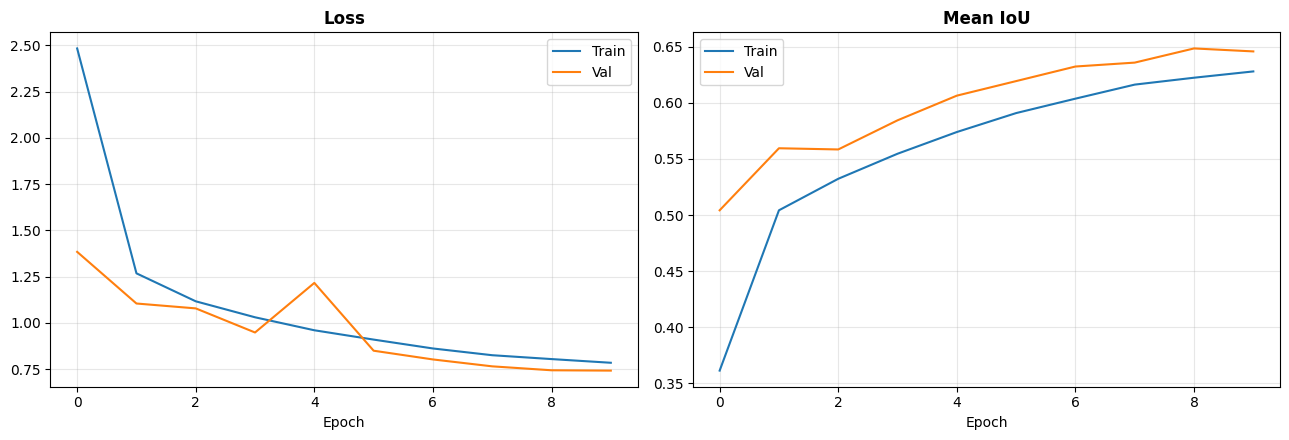

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_miou"], label="Train")
axes[1].plot(history["val_miou"], label="Val")
axes[1].set_title("Mean IoU", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1️2 Inference & Visualization

Loads the best checkpoint and renders input / ground truth / prediction / overlay panels.


[INFO] Loading best checkpoint for inference...
[INFO] Loaded checkpoint from epoch 9 (val mIoU=0.6487)


W0818 09:42:58.268000 23 torch/_inductor/utils.py:1679] [4/0] Not enough SMs to use max_autotune_gemm mode


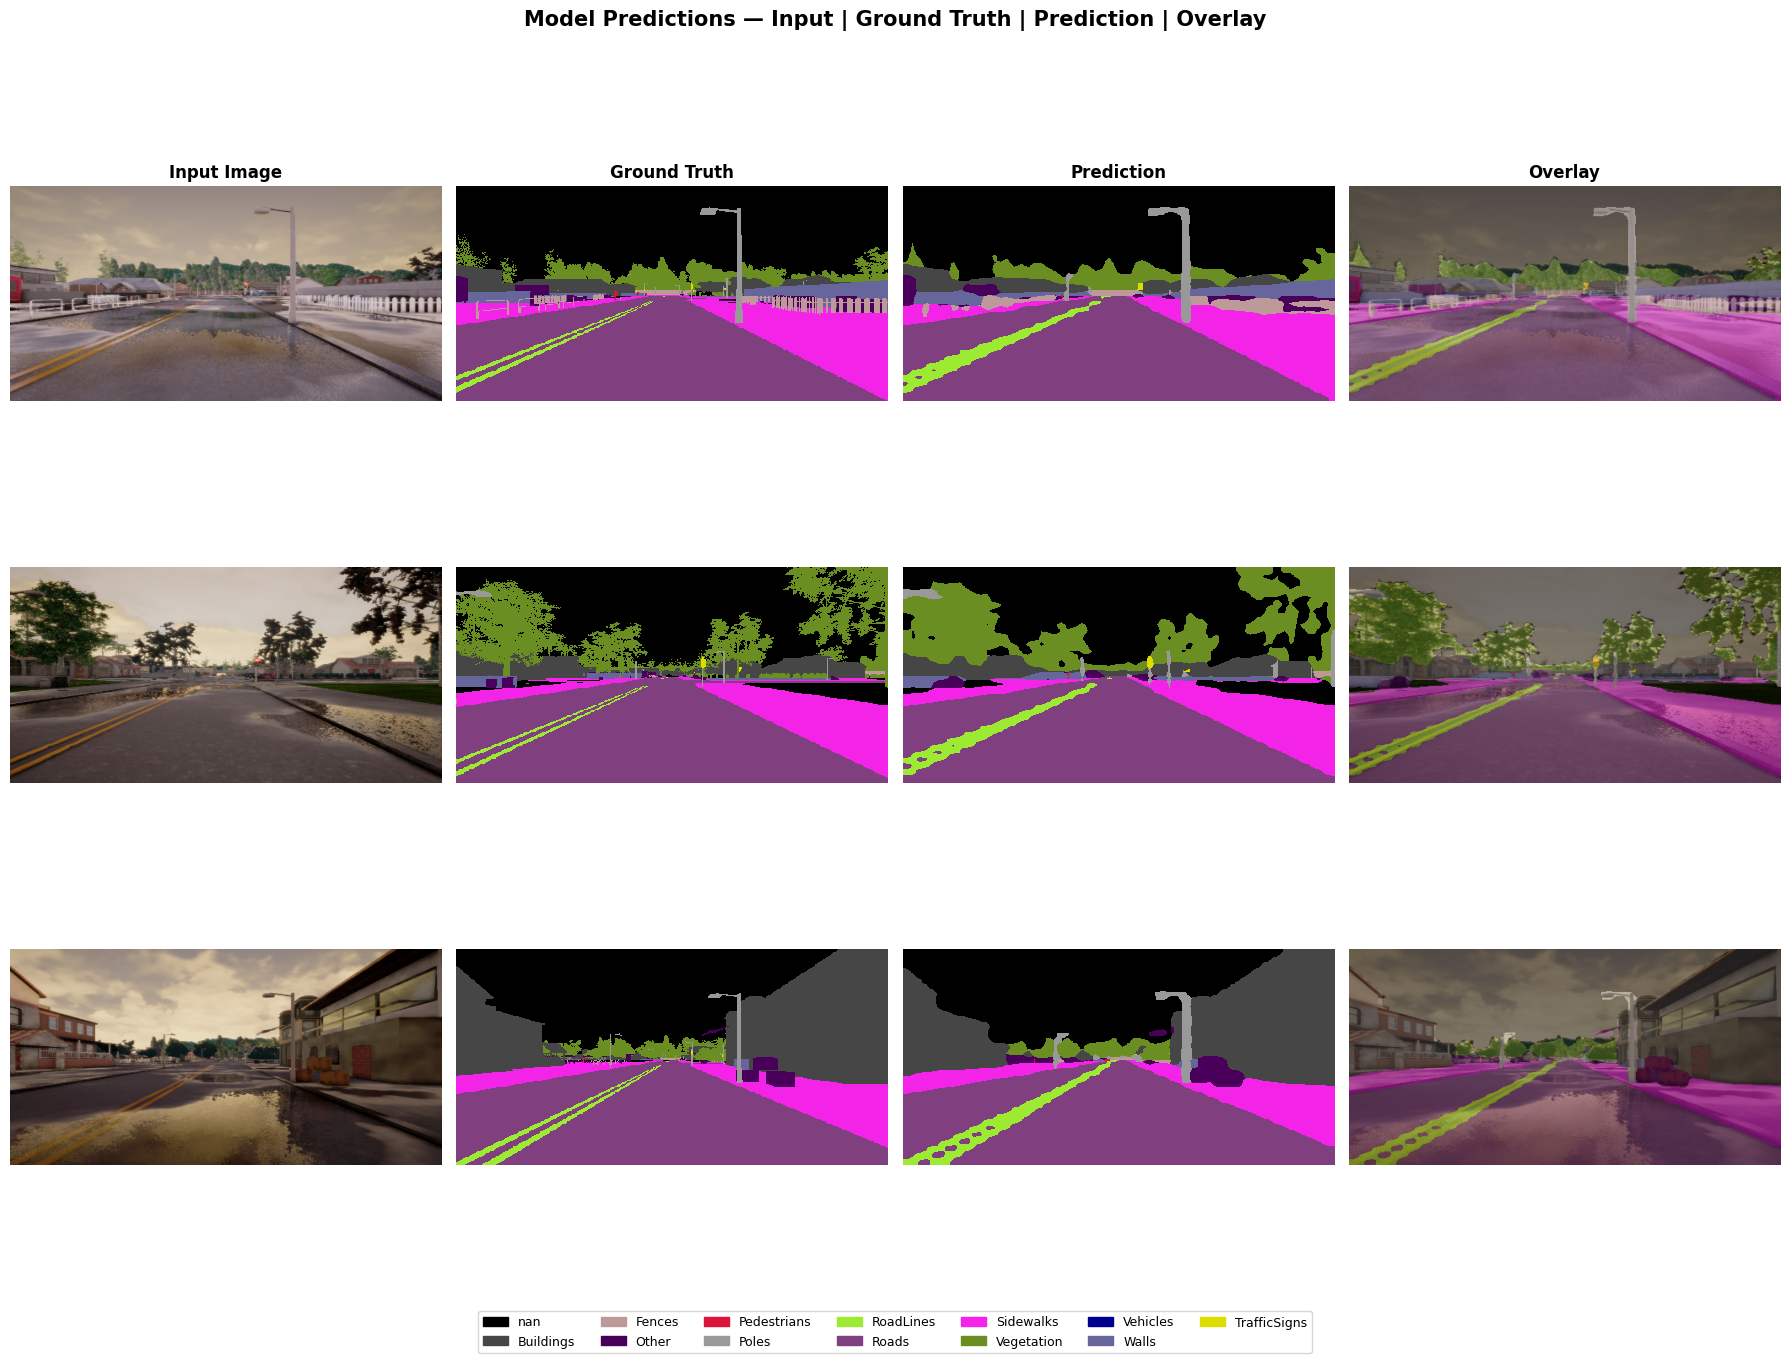


 Advanced pipeline complete. Best val mIoU: 0.6487
   Tips to push further: train longer, raise resolution to 512x1024, try backbone='resnet101',
   or swap in a stronger architecture (e.g. segmentation_models_pytorch's DeepLabV3+ / UNet++).


In [13]:
print("\n[INFO] Loading best checkpoint for inference...")
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"[INFO] Loaded checkpoint from epoch {ckpt['epoch']} (val mIoU={ckpt['miou']:.4f})")

cmap_colors = class_rgb.astype(np.float32) / 255.0
seg_cmap = mcolors.ListedColormap(cmap_colors)
seg_norm = mcolors.BoundaryNorm(np.arange(NUM_CLASSES + 1) - 0.5, NUM_CLASSES)

N_SAMPLES = 3
fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(18, 4.5 * N_SAMPLES))
fig.suptitle("Model Predictions — Input | Ground Truth | Prediction | Overlay", fontsize=15, fontweight="bold")

with torch.no_grad():
    for row, idx in enumerate(random.sample(range(len(val_ds)), N_SAMPLES)):
        img_t, mask_raw, img_rgb, _ = val_ds[idx]

        gt_mask = decode_mask_gpu(mask_raw.unsqueeze(0).to(device)).squeeze().cpu().numpy()

        with torch.amp.autocast("cuda", enabled=use_cuda, dtype=AMP_DTYPE):
            out = model(img_t.unsqueeze(0).to(device))
        logits = out["out"] if isinstance(out, dict) else out
        pred_mask = logits.argmax(1).squeeze().cpu().numpy()

        pred_rgb = cmap_colors[pred_mask]
        overlay = (0.55 * (img_rgb.astype(np.float32) / 255.0) + 0.45 * pred_rgb)

        axes[row, 0].imshow(img_rgb); axes[row, 0].axis("off")
        axes[row, 1].imshow(gt_mask, cmap=seg_cmap, norm=seg_norm, interpolation="nearest"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred_mask, cmap=seg_cmap, norm=seg_norm, interpolation="nearest"); axes[row, 2].axis("off")
        axes[row, 3].imshow(overlay); axes[row, 3].axis("off")

for col, title in enumerate(["Input Image", "Ground Truth", "Prediction", "Overlay"]):
    axes[0, col].set_title(title, fontweight="bold")

legend_patches = [mpatches.Patch(color=cmap_colors[i], label=class_names[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=legend_patches, loc="lower center", ncol=7, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print(f"\n Advanced pipeline complete. Best val mIoU: {ckpt['miou']:.4f}")
print("   Tips to push further: train longer, raise resolution to 512x1024, try backbone='resnet101',")
print("   or swap in a stronger architecture (e.g. segmentation_models_pytorch's DeepLabV3+ / UNet++).")